# Neural Computing and Deep Learning
## Week 12 – Attention Networks

This notebook covers:
- Preparing a Fibonacci sequence dataset for time series forecasting
- Using a SimpleRNN network for time series forecasting
- Adding a custom attention layer to the SimpleRNN network

---
## 1. Imports

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, SimpleRNN, Dense, Layer
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import tensorflow.keras.backend as K

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


---
## 2. The Dataset – Fibonacci Sequence

In the Fibonacci sequence, each number is the sum of the two before it:

`0, 1, 1, 2, 3, 5, 8, 13, 21, 34, ...`

We generate a sequence, normalise it, then create sliding-window samples of length `t` to predict the next value.

In [7]:
# Generate Fibonacci sequence of length n
def fib_sequence(n):
    seq = [0, 1]
    while len(seq) < n:
        seq.append(seq[-1] + seq[-2])
    return np.array(seq, dtype=float)

fib = fib_sequence(500)
print("First 10 Fibonacci numbers:", fib[:10])

First 10 Fibonacci numbers: [ 0.  1.  1.  2.  3.  5.  8. 13. 21. 34.]


In [8]:
# Normalise to [0, 1] so the network trains more easily
fib_norm = (fib - fib.min()) / (fib.max() - fib.min() + 1e-8)
print("Min:", fib_norm.min(), " Max:", fib_norm.max())

Min: 0.0  Max: 1.0


In [9]:
# Create sliding-window dataset:
# Each sample X[i] = fib[i : i+t_steps], target y[i] = fib[i+t_steps]
def make_dataset(seq, t_steps):
    X, y = [], []
    for i in range(len(seq) - t_steps):
        X.append(seq[i : i + t_steps])
        y.append(seq[i + t_steps])
    return np.array(X), np.array(y)

# Quick check with different window sizes
for n in [6, 8, 10]:
    X_check, y_check = make_dataset(fib_norm, n)
    print(f"n={n:2d}  →  X shape: {X_check.shape},  y shape: {y_check.shape}")

n= 6  →  X shape: (494, 6),  y shape: (494,)
n= 8  →  X shape: (492, 8),  y shape: (492,)
n=10  →  X shape: (490, 10),  y shape: (490,)


---
## 3. Prepare Training and Test Data

We use `time_steps = 5` and `hidden_units = 4` for the practical session models.

In [10]:
# Practical session parameters
time_steps   = 20
hidden_units = 4
batch_size   = 1
epochs_base  = 57   # quick training for the practical models

# Build dataset with time_steps=5
X_all, y_all = make_dataset(fib_norm, time_steps)
X_all = X_all.reshape(X_all.shape[0], time_steps, 1)  # shape: (samples, timesteps, 1)

# 80/20 train-test split
split = int(0.8 * len(X_all))
X_train, X_test = X_all[:split], X_all[split:]
y_train, y_test = y_all[:split], y_all[split:]

print(f"Training samples : {X_train.shape}")
print(f"Test samples     : {X_test.shape}")

Training samples : (384, 20, 1)
Test samples     : (96, 20, 1)


---
## 4. Model 1 – Simple RNN

A basic RNN with a single hidden layer and a Dense output node.

In [11]:
# Build Simple RNN model
rnn_input  = Input(shape=(time_steps, 1), name='rnn_input')
rnn_hidden = SimpleRNN(hidden_units, activation='tanh', name='simple_rnn')(rnn_input)
rnn_output = Dense(1, name='output')(rnn_hidden)

model_rnn = Model(inputs=rnn_input, outputs=rnn_output)
model_rnn.compile(optimizer='adam', loss='mse')
model_rnn.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rnn_input (InputLayer)          │ (None, 20, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 4)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29 (116.00 B)

 Trainable params: 29 (116.00 B)

 Non-trainable params: 0 (0.00 B)

In [12]:

history_1 = model_rnn.fit(
    X_train, y_train,
    epochs=epochs_base,
    batch_size=batch_size,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/57
384/384 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 4.8642e-06 - val_loss: 0.0357
Epoch 2/57
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 4.7242e-23 - val_loss: 0.0357
Epoch 3/57
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 1.0921e-24 - val_loss: 0.0357
Epoch 4/57
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0000e+00 - val_loss: 0.0357
Epoch 5/57
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0000e+00 - val_loss: 0.0357
Epoch 6/57
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0000e+00 - val_loss: 0.0357
Epoch 7/57
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0000e+00 - val_loss: 0.0357
Epoch 8/57
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0000e+00 - val_loss: 0.0357
Epoch 9/57
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0000e+00 - val_loss: 0.0357
Epoch 10/57
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0000e+00 - val_loss: 0.0357
Epoch 11/57
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0000e+00 - val_loss: 0.0357
Epoch 12

In [13]:
# Evaluate Simple RNN
train_mse = model_rnn.evaluate(X_train, y_train, verbose=0)
test_mse  = model_rnn.evaluate(X_test,  y_test,  verbose=0)

print(f"Simple RNN  →  Train MSE: {train_mse:.6f}  |  Test MSE: {test_mse:.6f}")

Simple RNN  →  Train MSE: 0.000000  |  Test MSE: 0.035652


---
## 5. Custom Attention Layer

The attention mechanism learns to assign importance weights to each timestep in the RNN output sequence, then produces a weighted sum as the context vector.

In [14]:
class AttentionLayer(Layer):
    """
    Simple additive (Bahdanau-style) attention layer.

    For each timestep, computes a score using a learnable weight matrix W
    and bias b, applies softmax to get attention weights, then returns
    the weighted sum of the input sequence.
    """

    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        # W maps each hidden state to a scalar score
        self.W = self.add_weight(
            name='attention_weight',
            shape=(input_shape[-1], 1),
            initializer='random_normal',
            trainable=True
        )
        # b is a bias term per timestep
        self.b = self.add_weight(
            name='attention_bias',
            shape=(input_shape[1], 1),
            initializer='zeros',
            trainable=True
        )
        super(AttentionLayer, self).build(input_shape)

    def call(self, x):
        # Score each timestep
        scores = K.tanh(K.dot(x, self.W) + self.b)
        # Convert scores to probabilities (attention weights)
        attention_weights = K.softmax(scores, axis=1)
        # Weighted sum of input sequence
        context_vector = x * attention_weights
        return K.sum(context_vector, axis=1)

print("AttentionLayer defined successfully.")

AttentionLayer defined successfully.


---
## 6. Model 2 – RNN with Attention Layer

Same architecture as Model 1 but with `return_sequences=True` so the RNN outputs a sequence, which is then fed into the attention layer.

In [15]:
# Build RNN + Attention model
attn_input  = Input(shape=(time_steps, 1), name='attn_input')
attn_rnn    = SimpleRNN(hidden_units, activation='tanh',
                        return_sequences=True, name='rnn_with_sequences')(attn_input)
attn_output = AttentionLayer(name='attention')(attn_rnn)
attn_pred   = Dense(1, name='output')(attn_output)

model_attn = Model(inputs=attn_input, outputs=attn_pred)
model_attn.compile(optimizer='adam', loss='mse')
model_attn.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ attn_input (InputLayer)         │ (None, 20, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn_with_sequences (SimpleRNN)  │ (None, 20, 4)          │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention (AttentionLayer)      │ (None, 4)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53 (212.00 B)

 Trainable params: 53 (212.00 B)

 Non-trainable params: 0 (0.00 B)

In [16]:

history_2 = model_attn.fit(
    X_train, y_train,
    epochs=epochs_base,
    batch_size=batch_size,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/57
384/384 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 5.0608e-07 - val_loss: 0.0144
Epoch 2/57
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 8.6784e-24 - val_loss: 0.0144
Epoch 3/57
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 3.8031e-24 - val_loss: 0.0144
Epoch 4/57
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 3.3707e-24 - val_loss: 0.0144
Epoch 5/57
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0000e+00 - val_loss: 0.0144
Epoch 6/57
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0000e+00 - val_loss: 0.0144
Epoch 7/57
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0000e+00 - val_loss: 0.0144
Epoch 8/57
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0000e+00 - val_loss: 0.0144
Epoch 9/57
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0000e+00 - val_loss: 0.0144
Epoch 10/57
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0000e+00 - val_loss: 0.0144
Epoch 11/57
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0000e+00 - val_loss: 0.0144
Epoch 12

In [17]:
# Evaluate RNN + Attention model
train_mse_attn = model_attn.evaluate(X_train, y_train, verbose=0)
test_mse_attn  = model_attn.evaluate(X_test,  y_test,  verbose=0)

print(f"RNN + Attention  →  Train MSE: {train_mse_attn:.6f}  |  Test MSE: {test_mse_attn:.6f}")

RNN + Attention  →  Train MSE: 0.000000  |  Test MSE: 0.014436


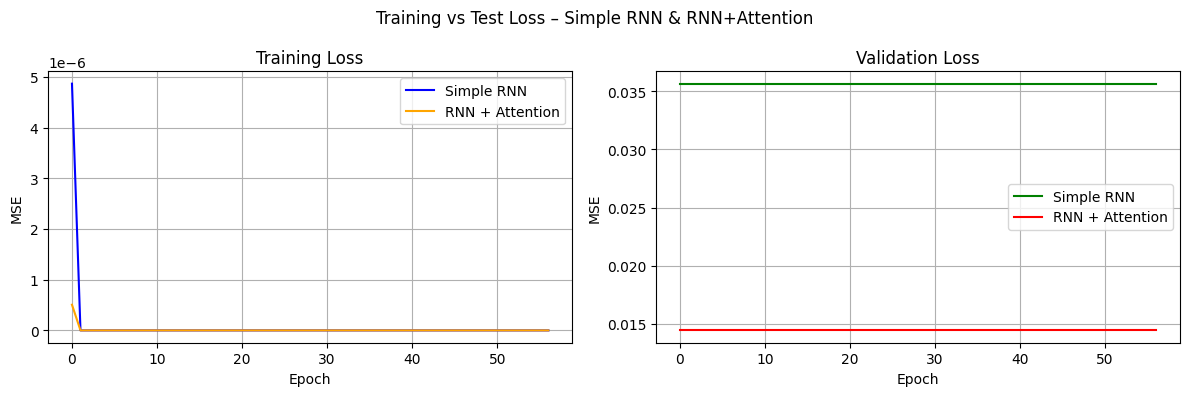

In [18]:
# Plot training and validation loss for both practical models
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Training loss
axes[0].plot(history_1.history['loss'], label='Simple RNN', color='blue')
axes[0].plot(history_2.history['loss'], label='RNN + Attention', color='orange')
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].grid(True)

# Validation loss
axes[1].plot(history_1.history['val_loss'], label='Simple RNN', color='green')
axes[1].plot(history_2.history['val_loss'], label='RNN + Attention', color='red')
axes[1].set_title('Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Training vs Test Loss – Simple RNN & RNN+Attention')
plt.tight_layout()
plt.show()

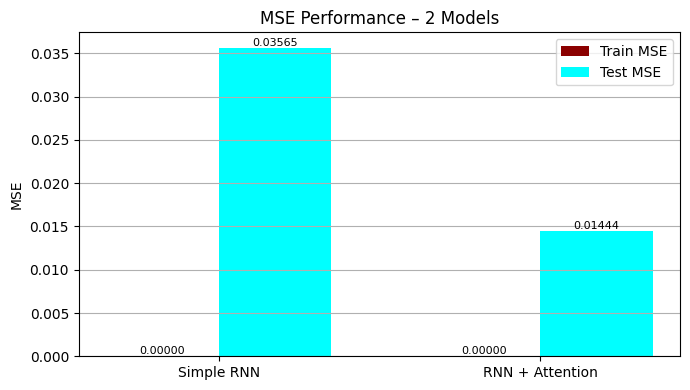

In [19]:
# MSE performance bar chart for the two practical models
models_list = ['Simple RNN', 'RNN + Attention']
train_vals  = [train_mse,      train_mse_attn]
test_vals   = [test_mse,       test_mse_attn]

x = np.arange(len(models_list))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 4))

# High-contrast colors
bars_train = ax.bar(x - width/2, train_vals, width, label='Train MSE', color='darkred')
bars_test  = ax.bar(x + width/2, test_vals,  width, label='Test MSE',  color='cyan')

ax.set_xticks(x)
ax.set_xticklabels(models_list)
ax.set_ylabel('MSE')
ax.set_title('MSE Performance – 2 Models')
ax.legend()
ax.grid(axis='y')

# Add value labels on top of each bar
for bar in list(bars_train) + list(bars_test):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h, f'{h:.5f}',
            ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

---
## 7. Lab Logbook – Modified Parameters calculation

**SID:** 2424077 → **Z = 2**

 Parameter     | Formula  | Value |
---------------|----------|-------|
 `epochs`      | Z + 50   | 57    |
 `patience`    | Z + 10   | 17    |
 `time_steps`  | fixed    | 20    |
 `hidden_units`| fixed    | 4     |


In [20]:


time_steps   = 20
hidden_units = 4
epochs       = 57
patience     = 17

print(f"epochs       = {epochs}")
print(f"patience     = {patience}")
print(f"time_steps   = {time_steps}")
print(f"hidden_units = {hidden_units}")

epochs       = 57
patience     = 17
time_steps   = 20
hidden_units = 4


In [21]:
# Rebuild dataset with time_steps = 20
X_lab, y_lab = make_dataset(fib_norm, time_steps)
X_lab = X_lab.reshape(X_lab.shape[0], time_steps, 1)

split_lab = int(0.8 * len(X_lab))
X_tr, X_te = X_lab[:split_lab], X_lab[split_lab:]
y_tr, y_te = y_lab[:split_lab], y_lab[split_lab:]

print(f"Lab train: {X_tr.shape}  |  Lab test: {X_te.shape}")

Lab train: (384, 20, 1)  |  Lab test: (96, 20, 1)


In [31]:

cb_early_stop = EarlyStopping(
    monitor='val_loss',
    patience=patience,
    restore_best_weights=True,
    verbose=1
)

cb_checkpoint = ModelCheckpoint(
    filepath='best_attention_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

print("Callbacks ready.")

Callbacks ready.


In [32]:
# Build Lab Model – RNN + Attention with time_steps=20
lab_input  = Input(shape=(time_steps, 1), name='lab_input')
lab_rnn    = SimpleRNN(hidden_units, activation='tanh',
                       return_sequences=True, name='lab_rnn')(lab_input)
lab_attn   = AttentionLayer(name='lab_attention')(lab_rnn)
lab_output = Dense(1, name='lab_output')(lab_attn)

model_lab = Model(inputs=lab_input, outputs=lab_output)
model_lab.compile(optimizer='adam', loss='mse')
model_lab.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lab_input (InputLayer)          │ (None, 20, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lab_rnn (SimpleRNN)             │ (None, 20, 4)          │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lab_attention (AttentionLayer)  │ (None, 4)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lab_output (Dense)              │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53 (212.00 B)

 Trainable params: 53 (212.00 B)

 Non-trainable params: 0 (0.00 B)

In [33]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

cb_early_stop = EarlyStopping(
    monitor='val_loss',
    patience=patience,
    restore_best_weights=True
)

cb_checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_loss',
    save_best_only=True
)

In [34]:
# Evaluate Lab Model
train_mse_lab = model_lab.evaluate(X_tr, y_tr, verbose=0)
test_mse_lab  = model_lab.evaluate(X_te, y_te, verbose=0)

print(f"Lab Model  →  Train MSE: {train_mse_lab:.6f}  |  Test MSE: {test_mse_lab:.6f}")

Lab Model  →  Train MSE: 0.000000  |  Test MSE: 0.014024


---
### 7a. Retrain Models 1 & 2 with time_steps=20 for a fair comparison

To plot all 3 models on the same graph, we retrain Simple RNN and RNN+Attention using the same `time_steps=20` dataset.

In [35]:
# Retrain Simple RNN with time_steps=20 for fair comparison
from tensorflow.keras.layers import Input, SimpleRNN, Dense
from tensorflow.keras.models import Model
rnn_in2  = Input(shape=(time_steps, 1))
rnn_h2   = SimpleRNN(hidden_units, activation='tanh')(rnn_in2)
rnn_out2 = Dense(1)(rnn_h2)
model_rnn2 = Model(inputs=rnn_in2, outputs=rnn_out2)
model_rnn2.compile(optimizer='adam', loss='mse')

history_rnn2 = model_rnn2.fit(
    X_tr, y_tr,
    epochs=epochs,
    batch_size=1,
    validation_data=(X_te, y_te),
    verbose=0   # silent – we only need the history for plotting
)

tr_mse_rnn2 = model_rnn2.evaluate(X_tr, y_tr, verbose=0)
te_mse_rnn2 = model_rnn2.evaluate(X_te, y_te, verbose=0)
print(f"Simple RNN (t=20)  →  Train MSE: {tr_mse_rnn2:.6f}  |  Test MSE: {te_mse_rnn2:.6f}")

Simple RNN (t=20)  →  Train MSE: 0.000000  |  Test MSE: 0.011073


In [36]:
# Retrain RNN + Attention with time_steps=20 for fair comparison
attn_in2  = Input(shape=(time_steps, 1))
attn_rn2  = SimpleRNN(hidden_units, activation='tanh', return_sequences=True)(attn_in2)
attn_ou2  = AttentionLayer()(attn_rn2)
attn_out2 = Dense(1)(attn_ou2)
model_attn2 = Model(inputs=attn_in2, outputs=attn_out2)
model_attn2.compile(optimizer='adam', loss='mse')

history_attn2 = model_attn2.fit(
    X_tr, y_tr,
    epochs=epochs,
    batch_size=1,
    validation_data=(X_te, y_te),
    verbose=0   # silent – we only need the history for plotting
)

tr_mse_attn2 = model_attn2.evaluate(X_tr, y_tr, verbose=0)
te_mse_attn2 = model_attn2.evaluate(X_te, y_te, verbose=0)
print(f"RNN+Attention (t=20)  →  Train MSE: {tr_mse_attn2:.6f}  |  Test MSE: {te_mse_attn2:.6f}")

RNN+Attention (t=20)  →  Train MSE: 0.000000  |  Test MSE: 0.017718


---
## 8. Results – All 3 Models


In [40]:
history_lab = model_lab.fit(
    X_tr, y_tr,
    epochs=epochs,
    batch_size=1,
    validation_data=(X_te, y_te),
    callbacks=[cb_early_stop, cb_checkpoint],
    verbose=1
)

Epoch 1/57
372/384 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0804e-07

384/384 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 3.4557e-08 - val_loss: 0.0141
Epoch 2/57
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 2.2274e-21 - val_loss: 0.0141
Epoch 3/57
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 1.1004e-08 - val_loss: 0.0142
Epoch 4/57
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 9.6337e-09 - val_loss: 0.0143
Epoch 5/57
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 5.3889e-15 - val_loss: 0.0143
Epoch 6/57
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 5.2137e-09 - val_loss: 0.0141
Epoch 7/57
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 6.8561e-15 - val_loss: 0.0141
Epoch 8/57
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 1.5533e-12 - val_loss: 0.0141
Epoch 9/57
373/384 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 8.6058e-09

384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 2.5003e-09 - val_loss: 0.0141
Epoch 10/57
370/384 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.5844e-09

384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 1.9200e-09 - val_loss: 0.0141
Epoch 11/57
381/384 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.8772e-09

384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 2.1517e-09 - val_loss: 0.0140
Epoch 12/57
384/384 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.3657e-09

...

384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 1.5073e-09 - val_loss: 0.0138
Epoch 28/57
377/384 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.6787e-09

384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 1.2990e-09 - val_loss: 0.0138
Epoch 29/57
373/384 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.2063e-09

384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 1.4198e-09 - val_loss: 0.0138
Epoch 30/57
372/384 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.3770e-09

384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 1.4638e-09 - val_loss: 0.0138
Epoch 31/57
374/384 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.3498e-09

384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 1.3170e-09 - val_loss: 0.0138
Epoch 32/57
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.2424e-08 - val_loss: 0.0141
Epoch 33/57
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 6.0074e-17 - val_loss: 0.0141
Epoch 34/57
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 1.0018e-18 - val_loss: 0.0141
Epoch 35/57
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 1.2107e-18 - val_loss: 0.0141
Epoch 36/57
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 1.5799e-18 - val_loss: 0.0141
Epoch 37/57
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 2.0995e-18 - val_loss: 0.0141
Epoch 38/57
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 3.5782e-18 - val_loss: 0.0141
Epoch 39/57
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.3327e-18 - val_loss: 0.0141
Epoch 40/57
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 2.3959e-17 - val_loss: 0.0141
Epoch 41/57
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 8.5362e-10 - val_loss: 0.0140
Epoch 42/57

In [41]:
print('history_lab' in globals())

True


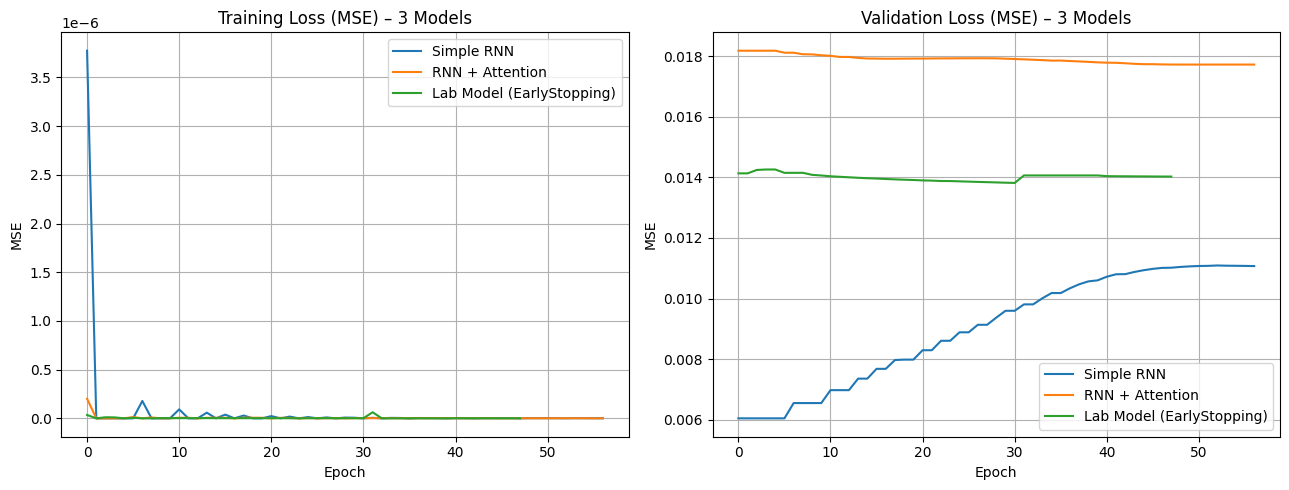

In [42]:
# Loss curves for all 3 models together
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Training loss
axes[0].plot(history_rnn2.history['loss'],   label='Simple RNN')
axes[0].plot(history_attn2.history['loss'],  label='RNN + Attention')
axes[0].plot(history_lab.history['loss'],    label='Lab Model (EarlyStopping)')
axes[0].set_title('Training Loss (MSE) – 3 Models')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].grid(True)

# Validation loss
axes[1].plot(history_rnn2.history['val_loss'],   label='Simple RNN')
axes[1].plot(history_attn2.history['val_loss'],  label='RNN + Attention')
axes[1].plot(history_lab.history['val_loss'],    label='Lab Model (EarlyStopping)')
axes[1].set_title('Validation Loss (MSE) – 3 Models')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

### 8b. MSE Performance Histogram – All 3 Models

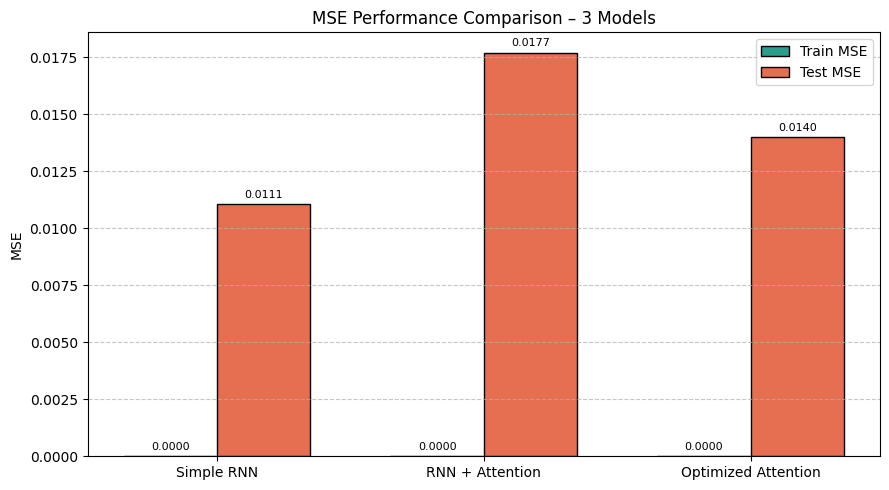

In [47]:
import numpy as np
import matplotlib.pyplot as plt

# Model names and MSE values
model_names = ['Simple RNN', 'RNN + Attention', 'Optimized Attention']
train_mses  = [tr_mse_rnn2, tr_mse_attn2, train_mse_lab]
test_mses   = [te_mse_rnn2, te_mse_attn2, test_mse_lab]

# X positions
x = np.arange(len(model_names))
width = 0.35

# Create figure
fig, ax = plt.subplots(figsize=(9, 5))

# Bars with updated colors (teal + coral)
bars_train = ax.bar(x - width/2, train_mses, width, label='Train MSE',
                    color='#2a9d8f', edgecolor='black')

bars_test  = ax.bar(x + width/2, test_mses, width, label='Test MSE',
                    color='#e76f51', edgecolor='black')

# Labels and title
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylabel('MSE')
ax.set_title('MSE Performance Comparison – 3 Models')

# Styling
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Value labels on bars
ax.bar_label(bars_train, fmt='%.4f', padding=3, fontsize=8)
ax.bar_label(bars_test, fmt='%.4f', padding=3, fontsize=8)

plt.tight_layout()
plt.show()

### 8c. Summary

In [46]:
print("=" * 60)
print("  RESULTS SUMMARY")
print("=" * 60)
print(f"  Simple RNN      | Train: {tr_mse_rnn2:.6f}  | Test: {te_mse_rnn2:.6f}")
print(f"  RNN + Attention | Train: {tr_mse_attn2:.6f}  | Test: {te_mse_attn2:.6f}")
print(f"  Lab Model       | Train: {train_mse_lab:.6f}  | Test: {test_mse_lab:.6f}")
print()
print(f"  Lab params: epochs={epochs}, patience={patience}, "
      f"time_steps={time_steps}, hidden_units={hidden_units}")
print()
print("  Best model saved → best_attention_model.keras")
print("=" * 60)

  RESULTS SUMMARY
  Simple RNN      | Train: 0.000000  | Test: 0.011073
  RNN + Attention | Train: 0.000000  | Test: 0.017718
  Lab Model       | Train: 0.000000  | Test: 0.014024

  Lab params: epochs=57, patience=17, time_steps=20, hidden_units=4

  Best model saved → best_attention_model.keras
